In [741]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [742]:
df = pd.read_csv("power_dataset.csv")

df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
0,7,2024-01-01 00:00:00,1.028338,50.237769,307.517387,17.897299,508.356414,179.224063,43.626140,57.414603,12.284398,1.648733,1,15.518346,0,0
1,15,2024-01-01 00:01:00,1.053432,50.169283,361.815640,168.500907,393.022613,281.283786,38.587320,79.678709,12.867102,9.830852,3,15.494397,0,1
2,11,2024-01-01 00:02:00,0.945917,50.443237,241.606054,49.128098,213.454317,223.428783,22.136379,80.592591,10.429979,1.663154,3,15.415086,0,0
3,8,2024-01-01 00:03:00,0.924887,50.000674,402.337623,125.638795,319.933523,250.153680,38.039710,51.173218,9.248422,7.629393,1,15.485418,0,0
4,7,2024-01-01 00:04:00,1.007855,49.911674,466.410157,109.596754,462.529359,127.042484,26.576337,62.849441,9.008734,12.087418,4,15.492712,0,0


In [743]:
df.shape


(20000, 16)

In [744]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   node_id           20000 non-null  int64  
 1   timestamp         20000 non-null  object 
 2   voltage           20000 non-null  float64
 3   frequency         20000 non-null  float64
 4   active_power      20000 non-null  float64
 5   reactive_power    20000 non-null  float64
 6   load_demand       20000 non-null  float64
 7   renewable_output  20000 non-null  float64
 8   temperature       20000 non-null  float64
 9   humidity          20000 non-null  float64
 10  energy_price      20000 non-null  float64
 11  power_loss        20000 non-null  float64
 12  region_id         20000 non-null  int64  
 13  stability_index   20000 non-null  float64
 14  fault_indicator   20000 non-null  int64  
 15  attack_label      20000 non-null  int64  
dtypes: float64(11), int64(4), object(1)
memo

In [745]:
df.describe()

,node_id,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10.093850,1.000030,50.000136,275.982591,104.436220,348.976194,151.476443,32.540640,60.053493,8.988598,10.548038,2.498050,15.476746,0.028000,0.10095
std,5.497613,0.050044,0.199824,129.876893,54.736176,144.624413,86.852150,7.208657,17.266076,3.474309,5.490174,1.115643,0.047663,0.164977,0.30127
min,1.000000,0.776720,49.140922,50.058505,10.005576,100.013765,0.004731,20.000164,30.000287,3.001757,1.000106,1.000000,15.269239,0.000000,0.00000
25%,5.000000,0.965726,49.864633,163.004828,56.436668,223.143031,76.125175,26.281981,45.332027,5.923650,5.785867,2.000000,15.447396,0.000000,0.00000
50%,10.000000,1.000265,50.000659,277.183891,104.706238,348.446384,152.035626,32.502302,60.029310,9.007834,10.538021,2.000000,15.479757,0.000000,0.00000
75%,15.000000,1.034294,50.135108,389.453852,151.459487,474.069480,227.091855,38.747978,74.874942,11.992225,15.277615,3.000000,15.509030,0.000000,0.00000
max,19.000000,1.223954,50.749076,499.943795,199.998488,599.960651,299.996815,44.997130,89.998979,14.999733,19.999606,4.000000,15.660982,1.000000,1.00000


In [746]:
df.isnull().sum()

node_id             0
timestamp           0
voltage             0
frequency           0
active_power        0
reactive_power      0
load_demand         0
renewable_output    0
temperature         0
humidity            0
energy_price        0
power_loss          0
region_id           0
stability_index     0
fault_indicator     0
attack_label        0
dtype: int64

In [747]:
print("Fault Distribution:")
print(df['fault_indicator'].value_counts())

print("\nAttack Distribution:")
print(df['attack_label'].value_counts())

Fault Distribution:
fault_indicator
0    19440
1      560
Name: count, dtype: int64

Attack Distribution:
attack_label
0    17981
1     2019
Name: count, dtype: int64


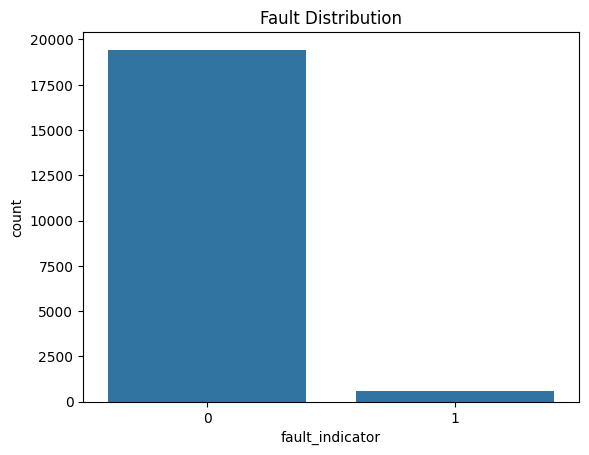

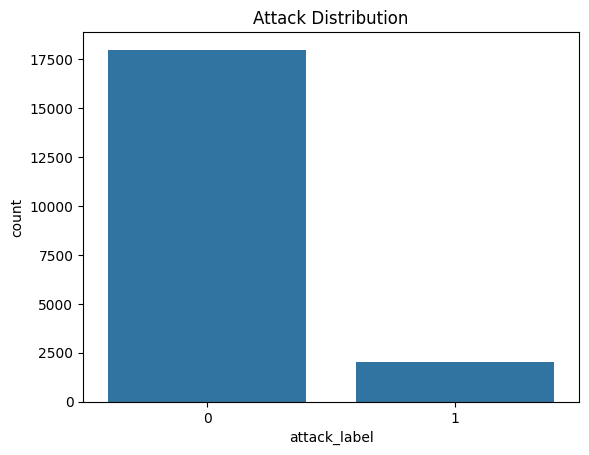

In [748]:
sns.countplot(x=df['fault_indicator'])
plt.title("Fault Distribution")
plt.show()

sns.countplot(x=df['attack_label'])
plt.title("Attack Distribution")
plt.show()

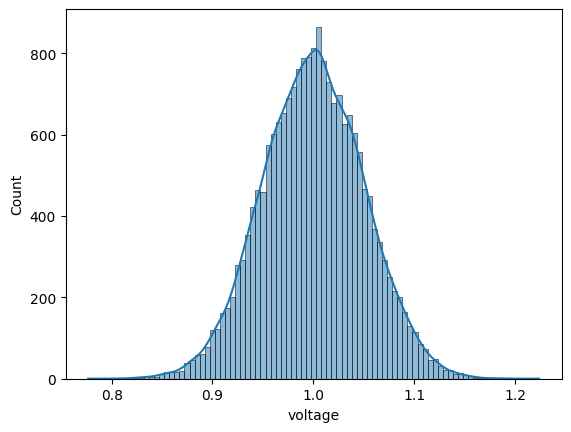

In [749]:
sns.histplot(df['voltage'], kde=True)
plt.show()

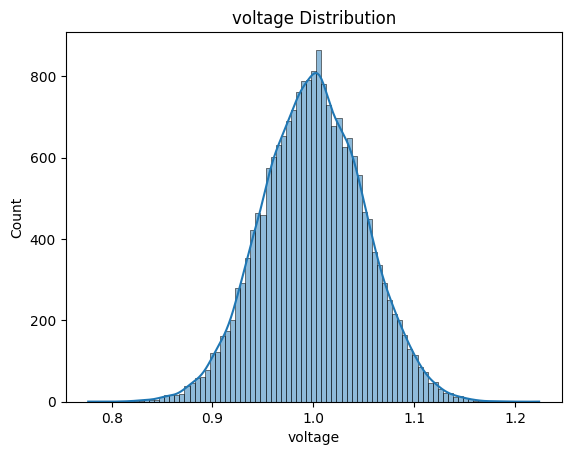

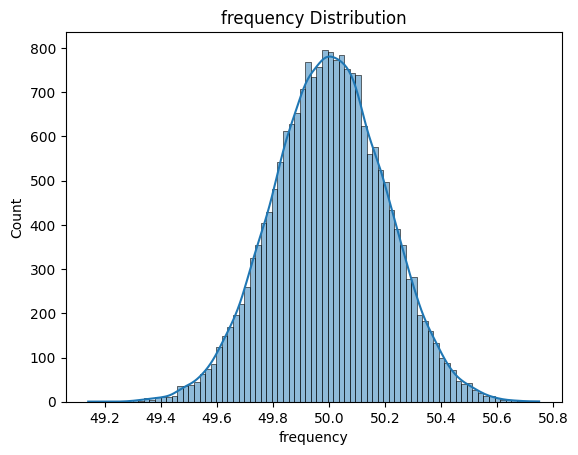

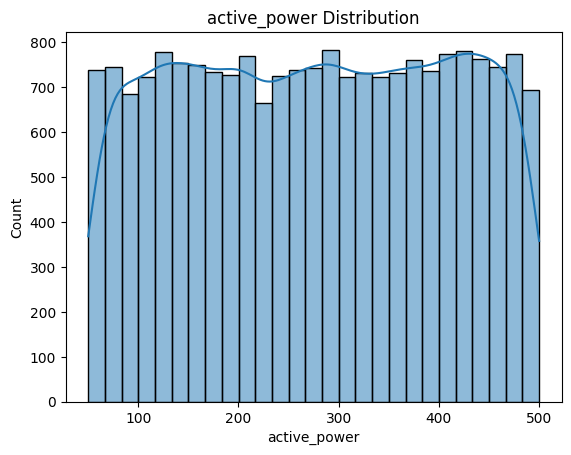

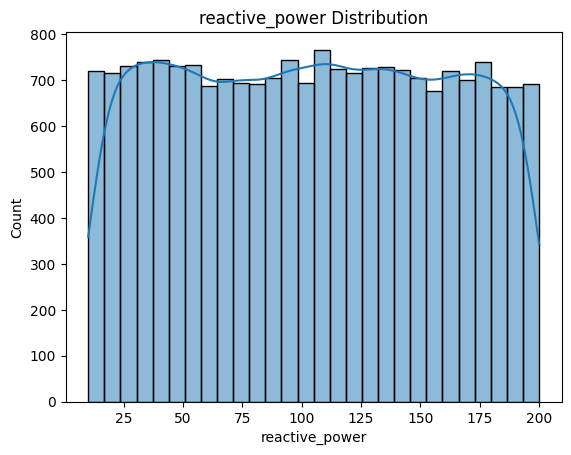

In [750]:
features = ['voltage', 'frequency', 'active_power', 'reactive_power']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [751]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['node_id', 'timestamp'])

In [752]:
df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
15,1,2024-01-01 00:15:00,1.045399,49.871849,204.189879,88.117805,408.453888,56.050106,36.050661,35.872846,14.866078,1.661316,3,15.559405,0,0
72,1,2024-01-01 01:12:00,0.990541,49.750545,255.736116,131.228752,354.982883,204.917731,25.225949,39.688957,3.627317,15.858115,4,15.432298,0,0
75,1,2024-01-01 01:15:00,0.968627,50.279394,170.735644,22.724623,297.229947,248.818421,24.051298,74.662274,9.925369,17.091625,1,15.411550,0,0
84,1,2024-01-01 01:24:00,1.041347,49.970846,344.395490,26.867610,208.172161,177.465013,37.560246,69.615805,5.021679,6.732106,3,15.537794,0,0
94,1,2024-01-01 01:34:00,1.018640,49.932940,340.012714,180.892998,387.879928,245.704293,42.451819,48.012628,5.686864,10.297114,1,15.506905,0,0


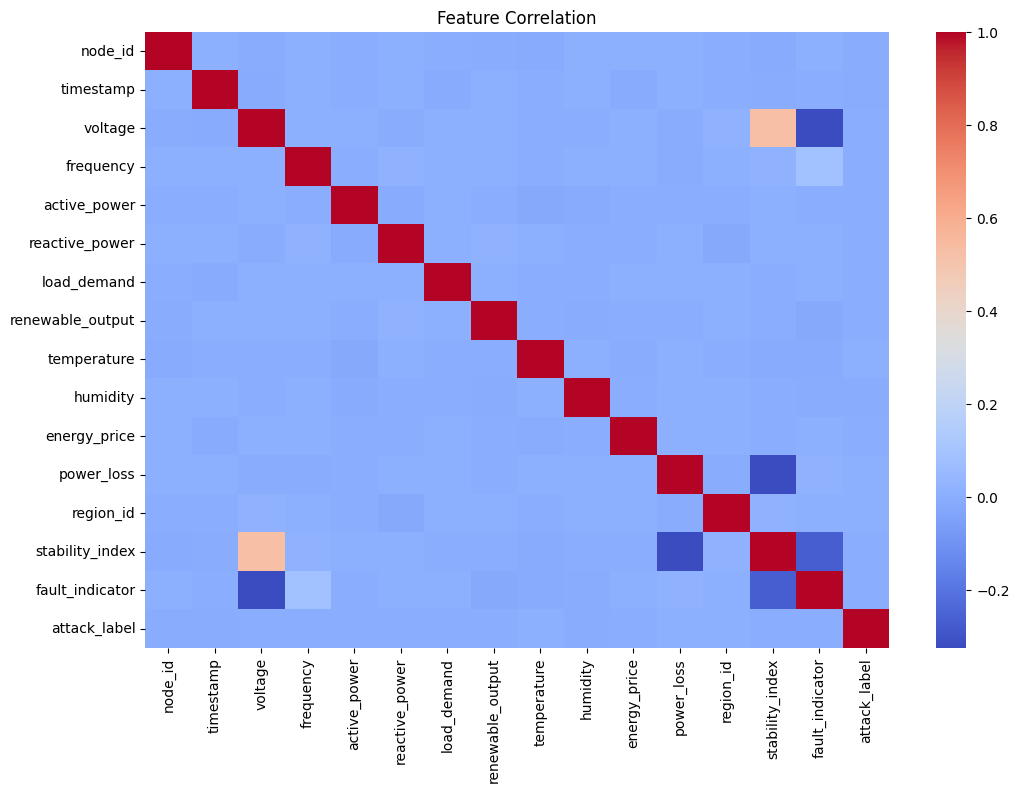

In [753]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [754]:
corr = df.corr()

print(corr['fault_indicator'].sort_values(ascending=False))
print(corr['attack_label'].sort_values(ascending=False))

fault_indicator     1.000000
frequency           0.088528
power_loss          0.017895
energy_price        0.007177
load_demand         0.007031
reactive_power      0.006736
region_id           0.004643
node_id             0.003112
active_power       -0.000478
timestamp          -0.002357
attack_label       -0.002547
humidity           -0.005826
temperature        -0.011479
renewable_output   -0.015969
stability_index    -0.272416
voltage            -0.325491
Name: fault_indicator, dtype: float64
attack_label        1.000000
region_id           0.010628
power_loss          0.008961
temperature         0.005797
voltage            -0.000109
reactive_power     -0.001789
fault_indicator    -0.002547
load_demand        -0.002984
renewable_output   -0.003406
energy_price       -0.003636
active_power       -0.003710
frequency          -0.003994
stability_index    -0.004084
timestamp          -0.004681
humidity           -0.005407
node_id            -0.006747
Name: attack_label, dtype: float64

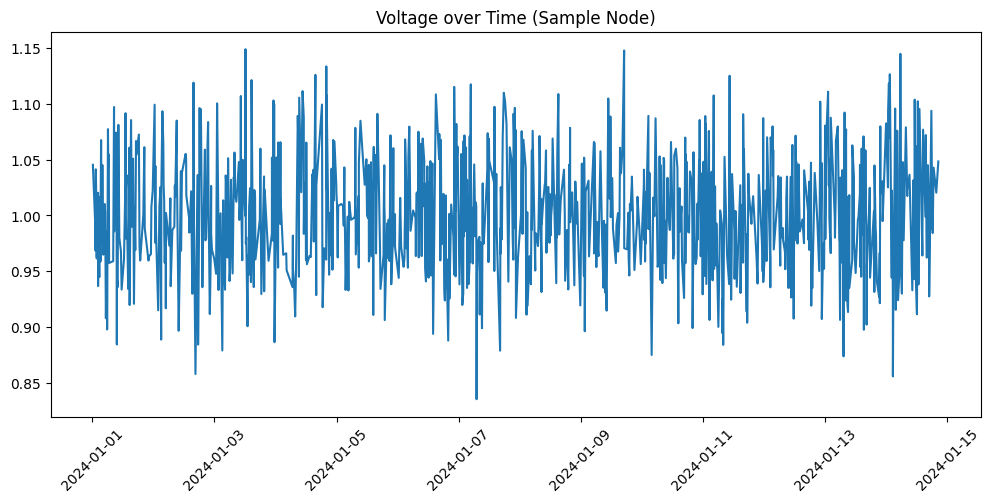

In [755]:
node_sample = df[df['node_id'] == df['node_id'].iloc[0]]

plt.figure(figsize=(12,5))
plt.plot(node_sample['timestamp'], node_sample['voltage'])
plt.title("Voltage over Time (Sample Node)")
plt.xticks(rotation=45)
plt.show()

🧠 8. FEATURE ENGINEERING (IMPORTANT PART)

In [756]:
df['voltage_dev'] = df['voltage'] - df['voltage'].mean()

In [757]:
df['freq_dev'] = df['frequency'] - df['frequency'].mean()

In [758]:
df['power_factor'] = df['active_power'] / (np.sqrt(df['active_power']**2 + df['reactive_power']**2))

In [759]:
df['voltage_roll_mean'] = df.groupby('node_id')['voltage'].rolling(5).mean().reset_index(0,drop=True)

In [760]:
df = df.dropna()

In [761]:
def create_label(row):
    if row['attack_label'] == 1:
        return 2
    elif row['fault_indicator'] == 1:
        return 1
    else:
        return 0

df['target'] = df.apply(create_label, axis=1)

df['target'].value_counts()

target
0    17417
2     2004
1      503
Name: count, dtype: int64

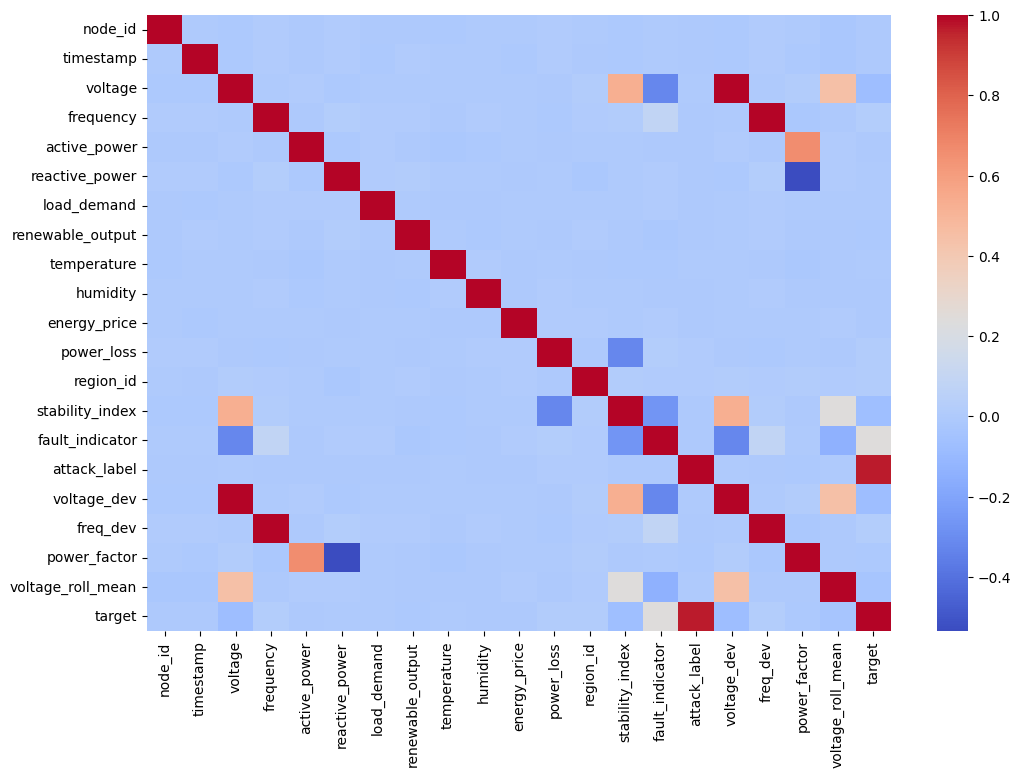

In [762]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [763]:
df['v_f_interaction'] = df['voltage'] * df['frequency']
df['power_ratio'] = df['active_power'] / (df['reactive_power'] + 1e-6)
df['load_power_ratio'] = df['load_demand'] / (df['active_power'] + 1e-6)

In [764]:
df['voltage_lag1'] = df.groupby('node_id')['voltage'].shift(1)
df['voltage_lag2'] = df.groupby('node_id')['voltage'].shift(2)

df['freq_lag1'] = df.groupby('node_id')['frequency'].shift(1)
df['power_lag1'] = df.groupby('node_id')['active_power'].shift(1)

In [765]:
df['voltage_roll_std'] = df.groupby('node_id')['voltage'].rolling(5).std().reset_index(0, drop=True)
df['freq_roll_std'] = df.groupby('node_id')['frequency'].rolling(5).std().reset_index(0, drop=True)

df['power_roll_mean'] = df.groupby('node_id')['active_power'].rolling(5).mean().reset_index(0, drop=True)

In [766]:
df['apparent_power'] = np.sqrt(df['active_power']**2 + df['reactive_power']**2)
df['power_efficiency'] = df['active_power'] / (df['load_demand'] + 1e-6)

In [767]:
df['temp_load_interaction'] = df['temperature'] * df['load_demand']
df['humidity_power_interaction'] = df['humidity'] * df['active_power']

In [768]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day

In [769]:
df['power_change'] = df.groupby('node_id')['active_power'].diff()
df['load_change'] = df.groupby('node_id')['load_demand'].diff()
df['freq_stability'] = df['frequency'].rolling(10).std()

In [770]:
df['power_diff'] = df.groupby('node_id')['active_power'].diff()
df['load_diff'] = df.groupby('node_id')['load_demand'].diff()
df['freq_diff'] = df.groupby('node_id')['frequency'].diff()

df['rolling_mean_freq'] = df.groupby('node_id')['frequency'].rolling(5).mean().reset_index(0,drop=True)
df['rolling_std_freq'] = df.groupby('node_id')['frequency'].rolling(5).std().reset_index(0,drop=True)

In [771]:
df['power_diff'] = df['power_diff'].fillna(0)
df['load_diff'] = df['load_diff'].fillna(0)
df['freq_diff'] = df['freq_diff'].fillna(0)
df = df.fillna(0)

In [772]:
df['freq_voltage_ratio'] = df['frequency'] / df['voltage']
df['power_voltage_ratio'] = df['active_power'] / df['voltage']
df['stability_power'] = df['stability_index'] * df['active_power']

In [773]:
df.isnull().sum()

node_id                       0
timestamp                     0
voltage                       0
frequency                     0
active_power                  0
reactive_power                0
load_demand                   0
renewable_output              0
temperature                   0
humidity                      0
energy_price                  0
power_loss                    0
region_id                     0
stability_index               0
fault_indicator               0
attack_label                  0
voltage_dev                   0
freq_dev                      0
power_factor                  0
voltage_roll_mean             0
target                        0
v_f_interaction               0
power_ratio                   0
load_power_ratio              0
voltage_lag1                  0
voltage_lag2                  0
freq_lag1                     0
power_lag1                    0
voltage_roll_std              0
freq_roll_std                 0
power_roll_mean               0
apparent

In [774]:
df = df.dropna()

In [775]:
df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,...,load_change,freq_stability,power_diff,load_diff,freq_diff,rolling_mean_freq,rolling_std_freq,freq_voltage_ratio,power_voltage_ratio,stability_power
94,1,2024-01-01 01:34:00,1.018640,49.932940,340.012714,180.892998,387.879928,245.704293,42.451819,48.012628,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,49.019235,333.790948,5272.544982
101,1,2024-01-01 01:41:00,0.963781,49.787662,333.412519,29.460117,144.801966,218.225560,27.931602,85.493810,...,-243.077962,0.0,-6.600195,-243.077962,-0.145278,0.000000,0.000000,51.658702,345.942292,5160.881597
107,1,2024-01-01 01:47:00,0.961405,49.875924,211.362187,169.538398,379.329578,293.424811,25.427721,67.890880,...,234.527612,0.0,-122.050332,234.527612,0.088262,0.000000,0.000000,51.878135,219.847079,3267.228084
137,1,2024-01-01 02:17:00,1.020304,50.333606,133.357110,83.227168,352.424673,242.256106,23.260555,56.236346,...,-26.904905,0.0,-78.005077,-26.904905,0.457682,0.000000,0.000000,49.331957,130.703277,2056.479156
138,1,2024-01-01 02:18:00,0.936673,50.044282,347.531462,99.347518,330.201028,166.252461,42.429869,75.285489,...,-22.223645,0.0,214.174351,-22.223645,-0.289324,49.994883,0.211011,53.427695,371.027498,5386.161489


In [776]:
corr = df.corr()

corr_target = corr['target'].abs().sort_values(ascending=False)
print(corr_target.head(20))

target                1.000000
attack_label          0.966848
fault_indicator       0.239320
freq_voltage_ratio    0.087541
voltage               0.078119
voltage_dev           0.078119
v_f_interaction       0.076492
stability_index       0.068932
voltage_roll_std      0.039572
voltage_roll_mean     0.032575
freq_dev              0.017345
frequency             0.017345
power_loss            0.013320
freq_diff             0.012809
freq_stability        0.012343
voltage_lag2          0.011546
region_id             0.010894
freq_roll_std         0.010257
rolling_std_freq      0.010257
power_factor          0.010131
Name: target, dtype: float64


In [777]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

protected_cols = ['target', 'fault_indicator', 'attack_label']

to_drop = [col for col in upper.columns 
           if any(upper[col] > 0.9) and col not in protected_cols]

df = df.drop(columns=to_drop)

In [778]:
def create_label(row):
    if row['attack_label'] == 1:
        return 2
    elif row['fault_indicator'] == 1:
        return 1
    else:
        return 0

df['target'] = df.apply(create_label, axis=1)

In [779]:
from xgboost import XGBClassifier

X = df.drop(columns=['target', 'timestamp'])
y = df['target']

model = XGBClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

attack_label             0.609993
fault_indicator          0.389823
voltage                  0.000133
stability_index          0.000032
voltage_roll_std         0.000005
freq_diff                0.000004
frequency                0.000003
voltage_roll_mean        0.000002
freq_roll_std            0.000002
rolling_mean_freq        0.000002
freq_stability           0.000001
power_efficiency         0.000000
power_roll_mean          0.000000
freq_lag1                0.000000
temp_load_interaction    0.000000
dtype: float32

In [780]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19924 entries, 94 to 19961
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   node_id                     19924 non-null  int64         
 1   timestamp                   19924 non-null  datetime64[ns]
 2   voltage                     19924 non-null  float64       
 3   frequency                   19924 non-null  float64       
 4   active_power                19924 non-null  float64       
 5   reactive_power              19924 non-null  float64       
 6   load_demand                 19924 non-null  float64       
 7   renewable_output            19924 non-null  float64       
 8   temperature                 19924 non-null  float64       
 9   humidity                    19924 non-null  float64       
 10  energy_price                19924 non-null  float64       
 11  power_loss                  19924 non-null  float64       

In [781]:
df.describe()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,...,power_roll_mean,power_efficiency,temp_load_interaction,humidity_power_interaction,hour,power_change,load_change,freq_stability,freq_diff,rolling_mean_freq
count,19924.000000,19924,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,...,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000,19924.000000
mean,10.094208,2024-01-07 23:17:28.253362688,1.000039,50.000062,275.986951,104.464534,348.934909,151.542051,32.532881,60.052443,...,274.883306,0.993183,11349.226076,16550.447129,11.457288,-0.063351,0.022759,0.194038,0.000005,49.809329
min,1.000000,2024-01-01 00:38:00,0.776720,49.140922,50.058505,10.005576,100.013765,0.004731,20.000164,30.000287,...,0.000000,0.084917,2061.513512,1546.222523,0.000000,-445.965013,-493.468396,0.000000,-1.183149,0.000000
25%,5.000000,2024-01-04 12:16:45,0.965723,49.864887,162.901206,56.453763,223.158316,76.246719,26.276408,45.332027,...,235.939582,0.467771,6889.063070,9013.564492,6.000000,-131.691456,-148.066538,0.161157,-0.192379,49.938950
50%,10.000000,2024-01-07 23:17:30,1.000280,50.000596,277.285292,104.727099,348.302338,152.104308,32.492011,60.029310,...,275.993961,0.791853,10741.782749,15061.915475,11.000000,0.924249,1.126872,0.191486,0.000694,49.999680
75%,15.000000,2024-01-11 10:18:15,1.034310,50.134975,389.504560,151.493846,474.025321,227.100943,38.737018,74.888488,...,315.949332,1.255416,15074.049951,22791.461006,17.000000,132.127753,147.811137,0.224891,0.189611,50.061022
max,19.000000,2024-01-14 21:19:00,1.223954,50.749076,499.943795,199.998488,599.960651,299.996815,44.997130,89.998979,...,468.617256,4.879602,26945.451912,44341.368906,23.000000,444.701820,494.743743,0.405258,1.133275,50.332952
std,5.497688,NaN,0.050049,0.199738,129.913013,54.743457,144.627275,86.824931,7.209260,17.272098,...,60.237554,0.762533,5432.709121,9364.925243,6.862671,183.517690,204.934274,0.046477,0.282175,3.083578


In [782]:
X = df.drop(columns=[
    'target',
    'timestamp',
    'fault_indicator',   # REMOVE (leakage)
    'attack_label'       # REMOVE (leakage)
])

y = df['target']

In [783]:
X = X.select_dtypes(include=['int64', 'float64'])

In [784]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [785]:
X_train.value_counts

<bound method DataFrame.value_counts of        node_id   voltage  frequency  active_power  reactive_power  \
9215        17  1.146680  49.836982    306.826448      175.917330   
13575        7  1.017513  50.090580    459.470547       90.953950   
13210        9  1.046905  50.310399    464.545200       89.720101   
14277        4  1.011712  50.010934    281.159167      101.943888   
4129         8  0.921256  49.879103    321.632866       47.398552   
...        ...       ...        ...           ...             ...   
13629        9  0.936877  50.158853    300.248638      150.477704   
15936        4  0.996113  50.213908    169.542071      184.419614   
12925       11  0.960643  50.455598    341.770296      195.195823   
2707        13  0.976875  50.070382    274.526025      185.466814   
17736        5  0.983942  50.289097    104.982822      157.896494   

       load_demand  renewable_output  temperature   humidity  energy_price  \
9215    426.154290        152.796561    43.005608  50

In [786]:
from xgboost import XGBClassifier
import pandas as pd

temp_model = XGBClassifier(eval_metric='mlogloss')
temp_model.fit(X_train, y_train)

importance = pd.Series(temp_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20).index

X_train_res = X_train[top_features]
X_test = X_test[top_features]

In [787]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train_res, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [788]:
from xgboost import XGBClassifier


from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_lambda=2,
    scale_pos_weight=2,   
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(
    X_train_main, y_train_main,
    eval_set=[(X_val, y_val)],
    
    verbose=False
)

xgb_pred = xgb.predict(X_test)

d:\conda\envs\smartgrid_gpu\lib\site-packages\xgboost\training.py:200: UserWarning: [17:13:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [789]:
xgb_pred = xgb.predict(X_test)

In [790]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8963613550815558
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3483
           1       0.84      0.96      0.89       101
           2       0.00      0.00      0.00       401

    accuracy                           0.90      3985
   macro avg       0.58      0.65      0.61      3985
weighted avg       0.81      0.90      0.85      3985



d:\conda\envs\smartgrid_gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\conda\envs\smartgrid_gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\conda\envs\smartgrid_gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


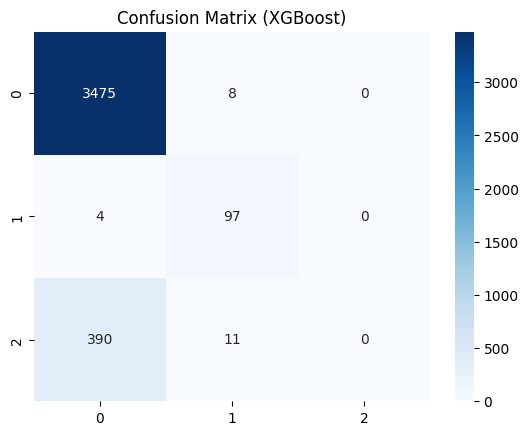

In [740]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.show()